In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px
import pycountry
import pycountry_convert as pc
import numpy as np
import random

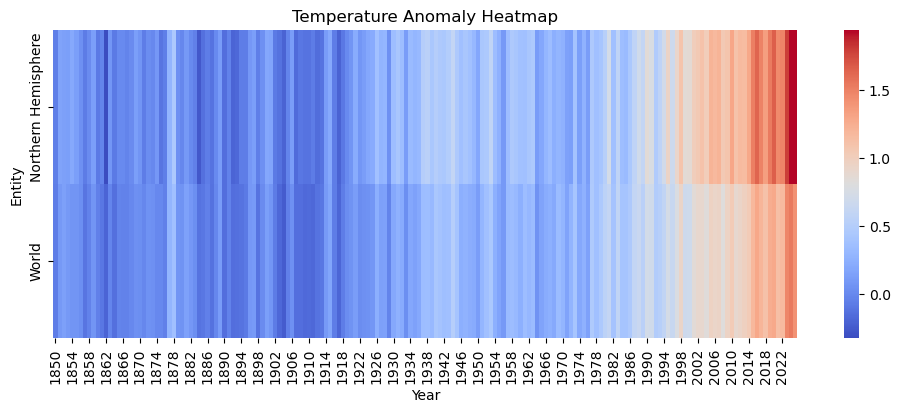

In [ ]:
# abnormal temperature line graph
import pandas as pd

url = "https://ourworldindata.org/explorers/co2.csv"
url1="https://ourworldindata.org/grapher/temperature-anomaly.csv"
url2="https://ourworldindata.org/explorers/climate-change.csv"


import seaborn as sns
import matplotlib.pyplot as plt




In [ ]:
#path = "/Users/qianxiaogou/Desktop/uni/Y3/datavis/cw/data/GlobalLandTemperaturesByCountry.csv"

#df=pd.read_csv(path)
import pandas as pd


anomalyTemp = "/Users/qianxiaogou/Desktop/uni/Y3/datavis/cw/data/annual-temperature-anomalies.csv"
df = pd.read_csv(anomalyTemp)

# preprocess
df = df.dropna(subset=["Temperature anomaly"])
df = df[df["Code"].notna()]   # remove regions like "World"

# OPTIONAL: focus recent years
df = df[df["Year"] >= 2000]

# create map
fig = px.choropleth(
    df,
    locations="Code",                     # ISO country code
    color="Temperature anomaly",         # anomaly value
    hover_name="Entity",
    animation_frame="Year",
    color_continuous_scale="RdBu_r",
    range_color=(-1, 2),                 # VERY IMPORTANT
    title="🌍 Global Temperature Anomaly Over Time"
)

# layout polish
fig.update_layout(
    title={"x": 0.5},
    coloraxis_colorbar=dict(title="Temp Anomaly (°C)")
)

# smoother animation
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 400

fig.show()

In [ ]:
co2 = "/Users/qianxiaogou/Desktop/uni/Y3/datavis/cw/data/co2.csv"
co = pd.read_csv(co2)
co = co.rename(columns={"CO₂ emissions per capita": "co2"})
co = co[co["Year"]>= 2000]
co.head()


,Entity,Code,Year,co2
51,Afghanistan,AFG,2000,0.052017
52,Afghanistan,AFG,2001,0.052706
53,Afghanistan,AFG,2002,0.062731
54,Afghanistan,AFG,2003,0.068608
55,Afghanistan,AFG,2004,0.052513


In [ ]:
#gas emission pie chart
url = "https://ourworldindata.org/grapher/ghg-emissions-by-sector.csv"

gas= pd.read_csv(url)
gas = gas[gas["Year"] >= 2000]


import pycountry
import pycountry_convert as pc
# =========================
# 3. CLEAN DATA
# =========================
exclude_cols = ["Entity", "Code", "Year"]
emission_cols = [col for col in gas.columns if col not in exclude_cols]

# convert to numeric
gas[emission_cols] = gas[emission_cols].apply(pd.to_numeric, errors='coerce')

# fill missing values
gas[emission_cols] = gas[emission_cols].fillna(0)

# =========================
# 4. COUNTRY → CONTINENT
# =========================
def country_to_continent(country_name):
    try:
        country_code = pycountry.countries.lookup(country_name).alpha_2
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        continent_map = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania",
            "AQ": "Antarctica"
        }
        return continent_map.get(continent_code)
    except:
        return None

gas["Continent"] = gas["Entity"].apply(country_to_continent)
# =========================
# 5. REMOVE PRE-AGGREGATED REGIONS
# =========================
regions = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania", "World"]
gas = gas[~gas["Entity"].isin(regions)]

# drop rows where continent is None
gas = gas.dropna(subset=["Continent"])


gas.head()


,Entity,Code,Year,Agriculture,Land-use change and forestry,Waste,Buildings,Industry,Manufacturing and construction,Transport,Electricity and heat,Fugitive emissions,Other fuel combustion,Aviation and shipping,Continent
10,Afghanistan,AFG,2000,11550000.0,0.0,1870000.0,200000.0,20000.0,230000.0,510000.0,160000.0,170000.0,0.0,20000.0,Asia
11,Afghanistan,AFG,2001,9740000.0,0.0,1890000.0,210000.0,50000.0,230000.0,510000.0,180000.0,80000.0,0.0,20000.0,Asia
12,Afghanistan,AFG,2002,12140000.0,0.0,2020000.0,210000.0,60000.0,560000.0,510000.0,150000.0,70000.0,0.0,20000.0,Asia
13,Afghanistan,AFG,2003,12510000.0,0.0,2180000.0,220000.0,70000.0,490000.0,720000.0,259999.0,80000.0,0.0,30000.0,Asia
14,Afghanistan,AFG,2004,12390000.0,0.0,2260000.0,250000.0,80000.0,240000.0,600000.0,230000.0,70000.0,0.0,30000.0,Asia


In [ ]:


# =========================
# 6. GROUP BY CONTINENT (KEEP FEATURES)
# =========================
continent_df = gas.groupby(
    ["Continent", "Year"], as_index=False
)[emission_cols].sum()


,Continent,Year,Agriculture,Land-use change and forestry,Waste,Buildings,Industry,Manufacturing and construction,Transport,Electricity and heat,Fugitive emissions,Other fuel combustion,Aviation and shipping
0,Africa,2000,706379999.0,648640000.0,110129999.0,149679998.0,45810000.0,104590000.0,161679997.0,326220000.0,410150000.0,13899999.0,41079998.0
1,Africa,2001,691729998.0,647720000.0,113179996.0,156450000.0,48220000.0,108139999.0,169680000.0,372519999.0,399510000.0,13020000.0,38589998.0
2,Africa,2002,723410000.0,636220000.0,121039997.0,163559999.0,53690001.0,109670000.0,178010000.0,383669998.0,367279999.0,12660000.0,36510000.0
3,Africa,2003,747809997.0,666950004.0,126949999.0,168669999.0,54459995.0,114540000.0,188949998.0,401580000.0,402069999.0,12969999.0,39479998.0
4,Africa,2004,755689997.0,660420003.0,132560000.0,174059999.0,59500001.0,121729999.0,196699999.0,433720015.0,409500000.0,14990000.0,37689999.0


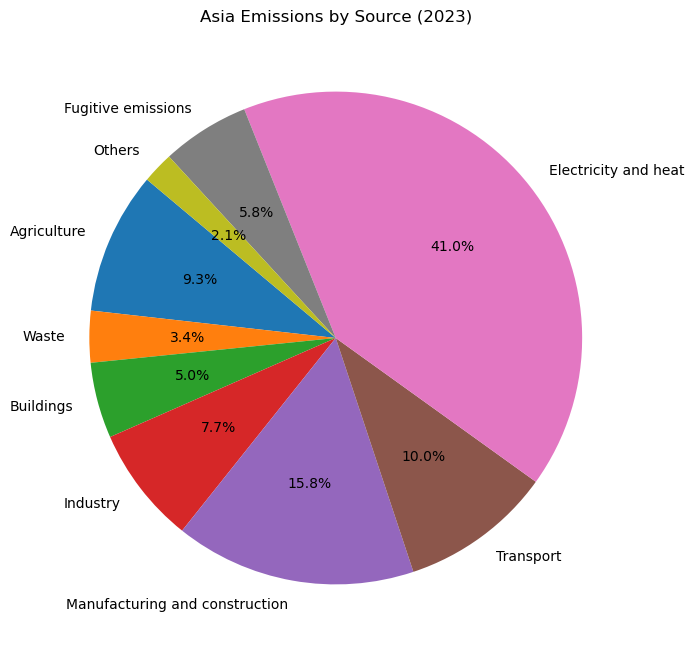

In [ ]:
# =========================
# 7. SELECT CONTINENT + YEAR
# =========================
continent = "Asia"   # 🔁 change this
year = continent_df["Year"].max()

subset = continent_df[
    (continent_df["Continent"] == continent) &
    (continent_df["Year"] == year)
]

continent_df.head()
# =========================
# 8. PREPARE PIE DATA
# =========================
source_data = subset[emission_cols].iloc[0]

# OPTIONAL: group small values into "Others"
threshold = 0.02
total = source_data.sum()

small = source_data[source_data / total < threshold]
large = source_data[source_data / total >= threshold]

final_data = large.copy()
if len(small) > 0:
    final_data["Others"] = small.sum()

# =========================
# 9. PLOT PIE CHART
# =========================
plt.figure(figsize=(8, 8))

plt.pie(
    final_data,
    labels=final_data.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title(f"{continent} Emissions by Source ({year})")

plt.show()

In [ ]:
# =========================
# 1. LOAD DATA
# =========================
disasterP = "/Users/qianxiaogou/Desktop/uni/Y3/datavis/cw/data/disaster.xlsx"
df = pd.read_excel(disasterP)
df = df[(df["Year"] >= 2000) & (df["Year"] <= 2025)]

# =========================
# 2. CLEAN COLUMNS
# =========================
df.columns = df.columns.str.strip()

df = df[[
    "Country",
    "ISO",
    "Disaster Type",
    "Latitude",
    "Longitude",
    "Start Year",
    "Total Affected",
    "Total Deaths"
]]

df = df.rename(columns={"Start Year": "Year"})

# =========================
# 3. CLEAN DATA
# =========================
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"])
df["Year"] = df["Year"].astype(int)

# sort + enforce correct animation order
df = df.sort_values("Year")
df["Year"] = pd.Categorical(
    df["Year"],
    categories=sorted(df["Year"].unique()),
    ordered=True
)

df["Total Affected"] = df["Total Affected"].fillna(0)
df["Total Deaths"] = df["Total Deaths"].fillna(0)

df["Disaster Type"] = df["Disaster Type"].astype(str)

# scale size
df["Affected_scaled"] = np.log1p(df["Total Affected"])

# count number of events per year per type
df_count = (
    df.groupby(["Year", "Disaster Type"])
    .size()
    .reset_index(name="Count")
)
df_total = df_count.groupby("Year")["Count"].sum().reset_index()
# =========================
# 4. COUNTRY CENTROIDS (fallback)
# =========================
country_centroids = {
    "USA": (39, -98), "CHN": (35, 103), "IND": (21, 78),
    "BRA": (-10, -55), "RUS": (60, 90), "AUS": (-25, 133),
    "IDN": (-5, 120), "CAN": (56, -106), "ARG": (-34, -64),
    "ZAF": (-30, 25), "MEX": (23, -102), "JPN": (36, 138),
    "DEU": (51, 10), "FRA": (46, 2), "GBR": (55, -3)
}

# =========================
# 5. JITTER FUNCTION
# =========================
def jitter_coords(lat, lon, scale=2):
    return (
        lat + random.uniform(-scale, scale),
        lon + random.uniform(-scale, scale)
    )

# =========================
# 6. FIX COORDINATES
# =========================
lat_fixed = []
lon_fixed = []

for _, row in df.iterrows():
    if pd.notna(row["Latitude"]) and pd.notna(row["Longitude"]):
        lat_fixed.append(row["Latitude"])
        lon_fixed.append(row["Longitude"])
    else:
        iso = row["ISO"]
        if iso in country_centroids:
            base_lat, base_lon = country_centroids[iso]
            lat, lon = jitter_coords(base_lat, base_lon, scale=2)
        else:
            lat, lon = None, None
        
        lat_fixed.append(lat)
        lon_fixed.append(lon)

df["Latitude_fixed"] = lat_fixed
df["Longitude_fixed"] = lon_fixed

# remove rows still without coords
df = df.dropna(subset=["Latitude_fixed", "Longitude_fixed"])

# =========================
# 7. PLOT
# =========================
fig = px.scatter_geo(
    df,
    lat="Latitude_fixed",
    lon="Longitude_fixed",
    color="Disaster Type",
    size="Affected_scaled",
    size_max=50,
    hover_name="Country",
    hover_data={
        "Year": True,
        "Total Deaths": True,
        "Total Affected": True,
        "Latitude_fixed": False,
        "Longitude_fixed": False
    },
    animation_frame="Year",
    projection="natural earth",
    color_discrete_sequence=px.colors.qualitative.Set1
)

# =========================
# 8. LAYOUT
# =========================
fig.update_layout(
    title="Global Natural Disaster Events Over Time",
    legend_title="Disaster Type"
)

fig.update_geos(
    showcountries=True,
    showcoastlines=True
)

fig_bar = px.bar(
    df_count,
    x="Disaster Type",
    y="Count",
    color="Disaster Type",
    animation_frame="Year",
    title="Number of Disasters by Type Over Time",
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig_bar.update_layout(
    xaxis_title="Disaster Type",
    yaxis_title="Number of Events"
)
for frame in fig_bar.frames:
    year = int(frame.name)
    
    total = df_total[df_total["Year"] == year]["Count"].values[0]
    
    frame.layout = dict(
        annotations=[
            dict(
                text=f"Total: {total}",
                x=0.95,
                y=0.95,
                xref="paper",
                yref="paper",
                showarrow=False,
                font=dict(size=16, color="black"),
                bgcolor="white"
            )
        ]
    )

# also show for initial frame
initial_year = df_count["Year"].min()
initial_total = df_total[df_total["Year"] == initial_year]["Count"].values[0]

fig_bar.update_layout(
    annotations=[
        dict(
            text=f"Total: {initial_total}",
            x=0.95,
            y=0.95,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=16, color="black"),
            bgcolor="white"
        )
    ]
)
# smoother animation
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 300

# =========================
# 9. SHOW
# =========================
fig.show()
fig_bar.show()

Index(['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'AID Contribution ('000 US$)', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI',
       'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update'],
      dtype='object')
